### Analyses the fraction due to Antarctic mass changes

In [1]:
import importlib
import sys
sys.path.append('../code')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import Kyrafunctions as ky

import SeaLevelContrib as slc

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')


In [2]:
importlib.reload(slc)
importlib.reload(ky)

<module 'SeaLevelContrib' from 'C:\\Users\\kyrab\\Github\\SLBudget\\notebooks\\../code\\SeaLevelContrib.py'>

In [3]:
#define data paths:
data_path = '../data/GravIs/'
Gravis_dir = '../outputs/Gravis_Antarctica/'

In [4]:
# Create yearly dataset for mass change patterns

#Antarctica: 
ant = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_AIS_GRID_TUD_0003.nc")
ant_y = ky.yearlygrace(ant) 

#Greenland: 
gre = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_GIS_GRID_TUD_0003.nc")
gre_y = ky.yearlygrace(gre) 

#display(ant_y)

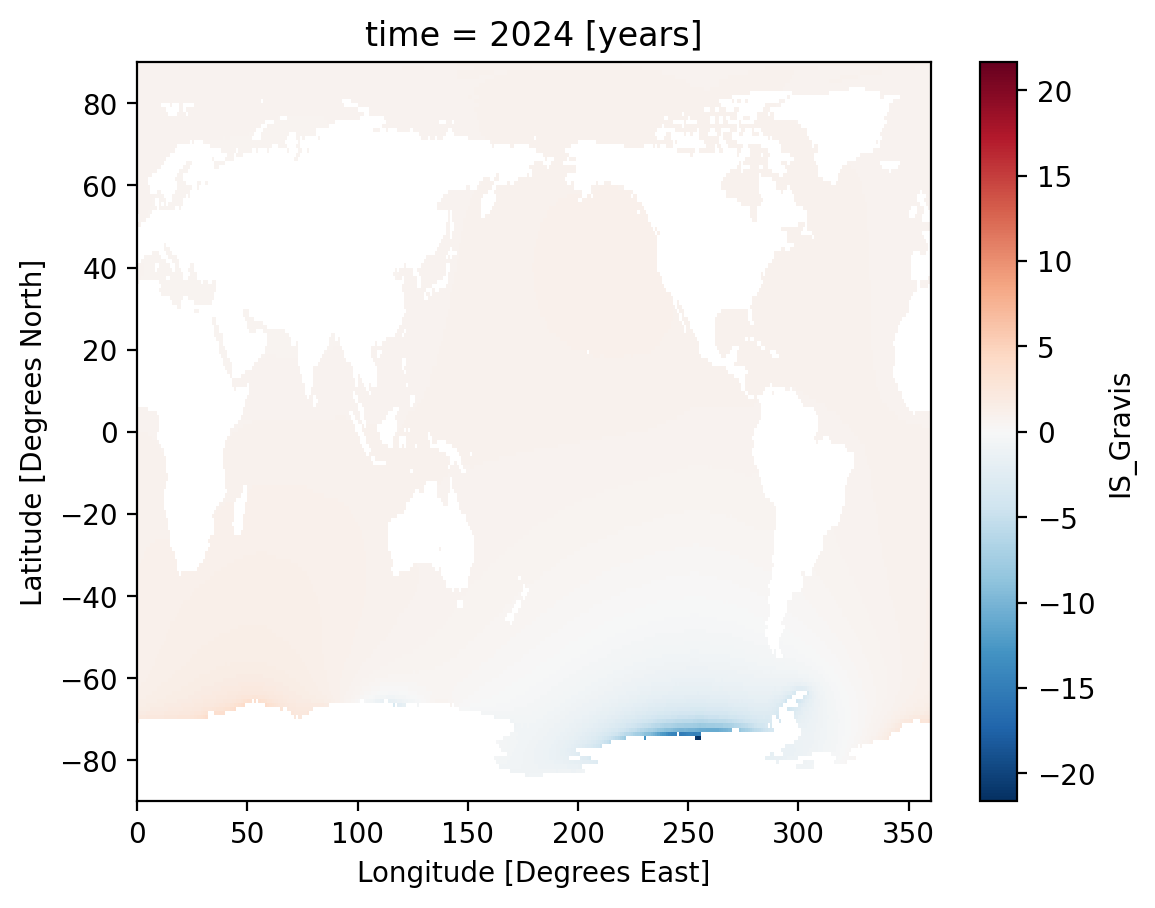

In [30]:
# Opens the dataset containing the the spatial patterns of sea level change based on the mass changes from GravIS and created using the sea level equation. 
# The sea level changes at the Dutch coast can be calculated based on this. 

Gravis_ant_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Ant_clean.nc')
Gravis_gre_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Gre_clean.nc')

#Optional: scale data by factor 1.2 or 1.1837950465122913
Gravis_ant_ds['IS_Gravis'] = Gravis_ant_ds['IS_Gravis']*1.1837950465122913
Gravis_ant_ds['Meanslr'] = Gravis_ant_ds['Meanslr']*1.1837950465122913

#display(Gravis_ant_ds)
#display(Gravis_gre_ds)
#Gravis_ant_ds['IS_Gravis'].isel(time=-1).plot()

### Plot sea level changes at tide gauge locations due to Antarctic mass change pattern

In [33]:
#Select tg stations and the region where the inpact on the sea level due to mass changes needs to be plotted. 

tg_id = [20, 22, 23, 24, 25, 32]
#Extract latitude and longitude from a tide gauge station from the list. 
tg_coord = slc.tg_lat_lon(tg_id[0])
#print(tg_coord)

# Extract coordinates
tg_coords = [slc.tg_lat_lon(tg) for tg in tg_id]
tg_lats = [c[0] for c in tg_coords]
tg_lons = [c[1] for c in tg_coords]


# Define region (Dutch coast)
lon_min, lon_max = 2,8 #3, 7
lat_min, lat_max = 49, 56 #51, 54

# Select region
da_region = Gravis_ant_ds['IS_Gravis'].sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max)
)


# Pick a specific time if dataset has time dimension
if 'time' in da_region.dims:
    da_region = da_region.isel(time=-1)#-da_region.isel(time=0)  # Last time step minus first timestep (first timestep is already 0 so no need for that) 


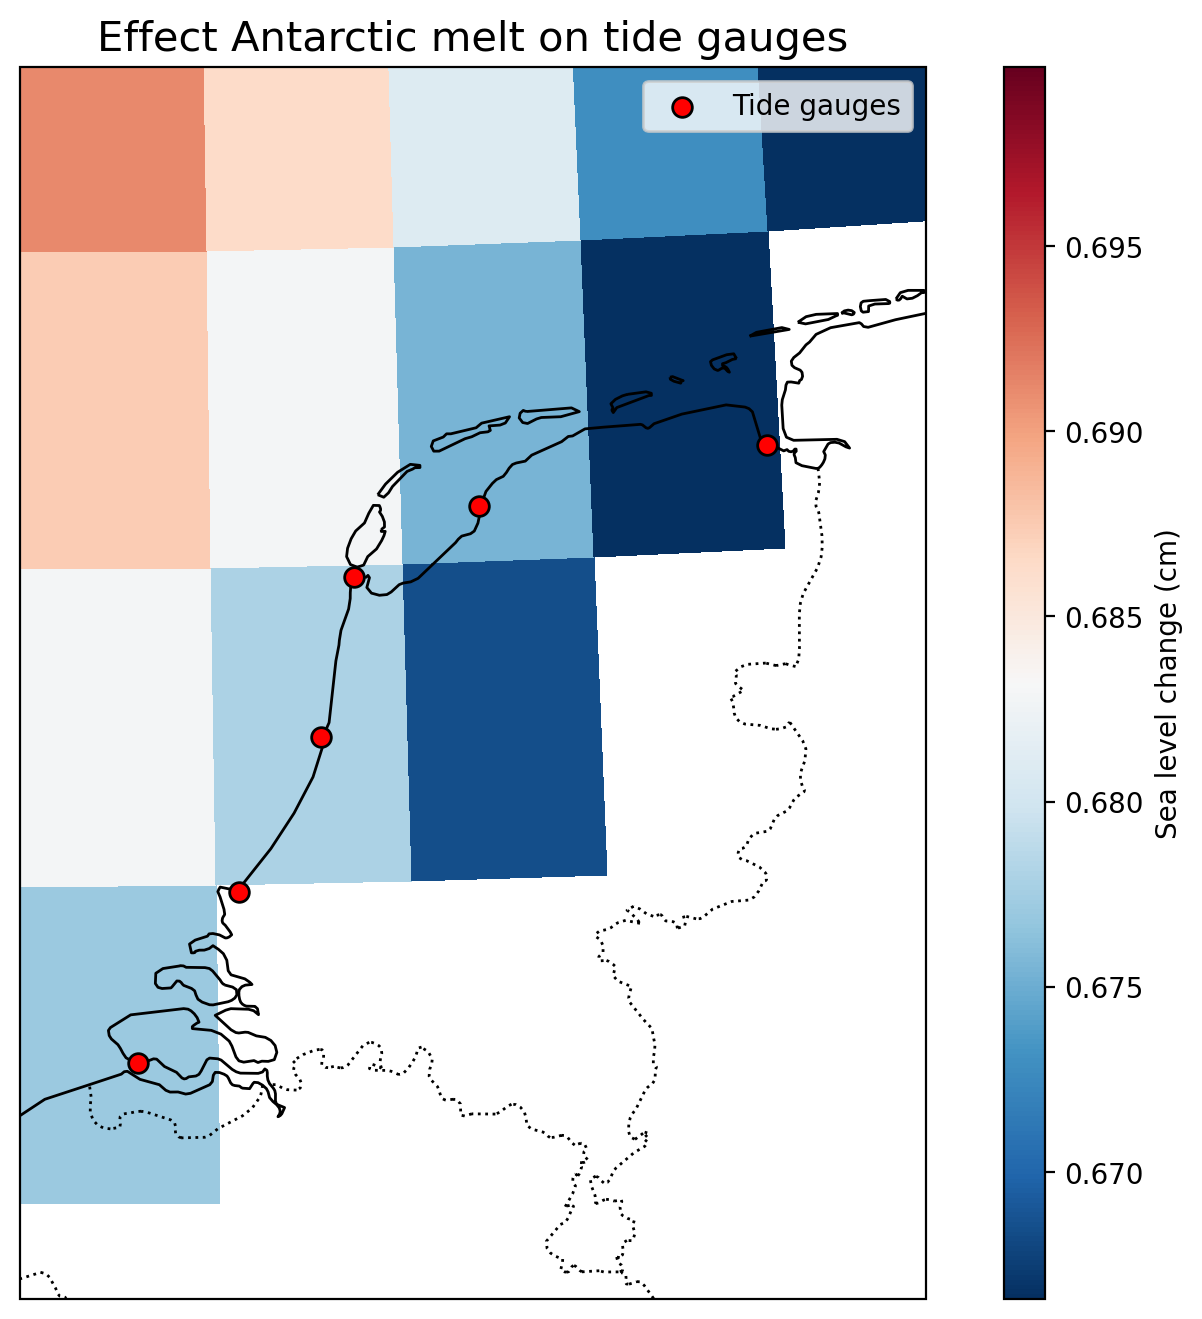

In [34]:
# ---- Projection suited for the Netherlands ----
proj = ccrs.UTM(zone=31)

# Netherlands extent (lon/lat)
NL_EXTENT = [3.0, 7.5, 50.7, 54.5]

fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={'projection': proj}
)

im = da_region.plot(
    ax=ax,
    cmap='RdBu_r',
    add_colorbar=True,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        'label': 'Sea level change (cm)',
        'shrink': 1,
        'aspect': 30
    }
)

ax.scatter(
    tg_lons,
    tg_lats,
    color='red',
    edgecolor='black',
    s=50,
    marker='o',
    label='Tide gauges',
    zorder=10,
    transform=ccrs.PlateCarree()
)

ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Apply EXACT same extent
ax.set_extent(NL_EXTENT, crs=ccrs.PlateCarree())

ax.set_title('Effect Antarctic melt on tide gauges', fontsize=15)
ax.legend()

plt.show()


### Calculate mean sea level rise at Dutch coast (mean over all tg stations) 

In [27]:
## load file with rise antarctica to calculate the fraction: 
tg_id = [20, 22, 23, 24, 25, 32] #tg stations to calculate the mean @dutch coast #use 23 in stead of 22 for now 

all_GRAVANT = []
all_GRAVGRE = []

for tg in tg_id: 
    tg_coord = slc.tg_lat_lon(tg)
    sel_da = Gravis_ant_ds['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
    sel_da_gre = Gravis_gre_ds['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
    loc_da = sel_da.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')
    loc_da_gre = sel_da_gre.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')

    fr_name = {
        'tws' : 'TWS', 
        'AIS' : 'Antarctica', 
        'GrIS' : 'Greenland', 
        'glac' : 'Glaciers',
        'grav': 'Ant_gravis',
        'grav2': 'Gre_gravis'}
 
    GRAVANT = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav']) 
    GRAVGRE = loc_da_gre.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav2'])  
    #print(f'tgid{tg}')
    #display(GRAVANT)
    all_GRAVANT.append(GRAVANT)
    all_GRAVGRE.append(GRAVGRE)


# Compute mean of tide gauges: 

def mean_across_gauges(list_of_series):
    return pd.concat(list_of_series, axis=1).mean(axis=1)

# Compute mean time series for each contribution
mean_GRAVANT = mean_across_gauges(all_GRAVANT)
mean_GRAVGRE = mean_across_gauges(all_GRAVGRE)

# Combine all mean series into a single dataframe
mean_df = pd.DataFrame({
    #'Antarctica_mean': mean_ANT,
   # 'Greenland_mean': mean_GRE,
    'Ant_gravis_mean': mean_GRAVANT,
    'Gre_gravis_mean': mean_GRAVGRE
})


# Ensure the index is numeric or datetime
mean_df.index = pd.to_numeric(mean_df.index, errors='coerce')


#display(all_GRAVANT)
display(mean_df)

,Ant_gravis_mean,Gre_gravis_mean
time,,
2002,0.000000,0.000000
2003,0.029048,0.009851
2004,0.059572,0.013824
2005,0.070121,0.011643
2006,0.058111,0.015205
2007,0.101027,0.019718
2008,0.183176,0.032020
2009,0.168140,0.044154
2010,0.218463,0.054499


In [9]:
print(type(mean_df['Ant_gravis_mean']))
print(type(Gravis_ant_ds['Meanslr']))

<class 'pandas.core.series.Series'>
<class 'xarray.core.dataarray.DataArray'>


### Calculate the fraction (different options: based on running mean, yearly data or total mass changes within the period between 2002 and 2024

In [10]:
# Fraction cummulative data:
dutch_coast = mean_df['Ant_gravis_mean'] # dutch coast raw values - factor 1.2 is used. 
mean_world = Gravis_ant_ds['Meanslr'].to_series()  #this is now a data array but to make sure it works thte same translate it to a series , factor 1.2 is used 
fraction = dutch_coast/mean_world

#display(mean_world)


# Fractom using yearly data: 
dutch_c = dutch_coast.diff()  # dutch coast per year
mean_w = mean_world.diff() #global mean per year 
fractionperyear = dutch_c/mean_w

# Cummulative data running mean: 
dutch_coast_5y = dutch_coast.rolling(window=5, center=True).mean()   #min periods=1 uses less data at the boundaries
mean_world_5y   = mean_world.rolling(window=5, center=True).mean()
fraction_5y = dutch_coast_5y/mean_world_5y

# Yearly data running
dutch_c_5y =  dutch_c.rolling(window=5, center=True).mean() 
mean_w_5y =  mean_w.rolling(window=5, center=True).mean()
fractionperyearrun = dutch_c_5y/mean_w_5y

# Yearly data running method 2 (does it produce the same? just to be sure 
#dutrun = dutch_coast_5y.diff()   
#worldrun = mean_world_5y.diff()
#peryearfrac = dutrun/worldrun


#only use the running mean of the yearly data 

combined2= pd.DataFrame({
   # 'Dutch coast': dutch_coast, 
   # 'Global mean sea level rise': mean_world,
   # 'Fraction (Dutch/global mean )': fraction,

   # 'Dutch coast running mean 5y': dutch_coast_5y,
   # 'Global running mean 5y': mean_world_5y, 
   # 'Fraction using running means': fraction_5y,
    
   # 'Dutch absolute': dutch_c,
   # 'Global absoolute': mean_w,
   # 'Fraction per year': fractionperyear,
    
    'Dutch absolute running': dutch_c_5y, 
    'Global mean absolute running 5y': mean_w_5y,
    'Fraction running per year': fractionperyearrun
})

display(combined2)



# Nicer table 
# Styling: 
def highlight_fraction_cols(s):
    """Highlights columns with 'Fraction' in their name."""
    is_fraction = 'Fraction' in s.name
    return ['background-color: lightyellow' if is_fraction else '' for _ in s]

# 
# 1. Border after the 1st column ('Dutch coast') to exclude it from the main grouping.
# 2. Borders after columns 4, 7, and 10 to group the remaining 11 columns into (3, 3, 3, 2).
# (These columns are Global, Fraction, Dutch)
styles = [
    # Border after the 1st column (excluding it from the main 3-grouping)
    {'selector': 'th.col_heading.level0:nth-child(1)', 'props': [('border-right', '3px solid #666666')]},
    {'selector': 'td:nth-child(1)', 'props': [('border-right', '3px solid #666666')]},

    # Borders after the 4th, 7th, and 10th columns to create the triplets
    # (Global mean SL, Fraction, Dutch coast running mean 5y) and subsequent groups
    {'selector': 'th.col_heading.level0:nth-child(4)', 'props': [('border-right', '3px solid #666666')]},
    {'selector': 'td:nth-child(4)', 'props': [('border-right', '3px solid #666666')]},
    
    {'selector': 'th.col_heading.level0:nth-child(7)', 'props': [('border-right', '3px solid #666666')]},
    {'selector': 'td:nth-child(7)', 'props': [('border-right', '3px solid #666666')]},
    
    {'selector': 'th.col_heading.level0:nth-child(10)', 'props': [('border-right', '3px solid #666666')]},
    {'selector': 'td:nth-child(10)', 'props': [('border-right', '3px solid #666666')]}
]

combined2_2005 = combined2.loc[2005:] 

# Apply the Styling 
styled_combined2_2005 = (
    combined2_2005.style
    # Apply the highlighting to the Fraction columns
    .apply(highlight_fraction_cols, axis=0) 
    # Apply the visual grouping borders
    .set_table_styles(styles)
    # Format all numeric columns to 4 decimal places
    .format('{:.4f}')
)

# Display styled table
display(styled_combined2_2005)


,Dutch absolute running,Global mean absolute running 5y,Fraction running per year
time,,,
2002,NaN,NaN,NaN
2003,NaN,NaN,NaN
2004,NaN,NaN,NaN
2005,0.020205,0.019713,1.024971
2006,0.030826,0.030217,1.020135
2007,0.021714,0.023362,0.929431
2008,0.029668,0.031707,0.935702
2009,0.038487,0.041558,0.926106
2010,0.033604,0.037158,0.904356


,Dutch absolute running,Global mean absolute running 5y,Fraction running per year
time,,,
2005,0.0202,0.0197,1.0250
2006,0.0308,0.0302,1.0201
2007,0.0217,0.0234,0.9294
2008,0.0297,0.0317,0.9357
2009,0.0385,0.0416,0.9261
2010,0.0336,0.0372,0.9044
2011,0.0308,0.0348,0.8848
2012,0.0476,0.0491,0.9695
2013,0.0529,0.0531,0.9974


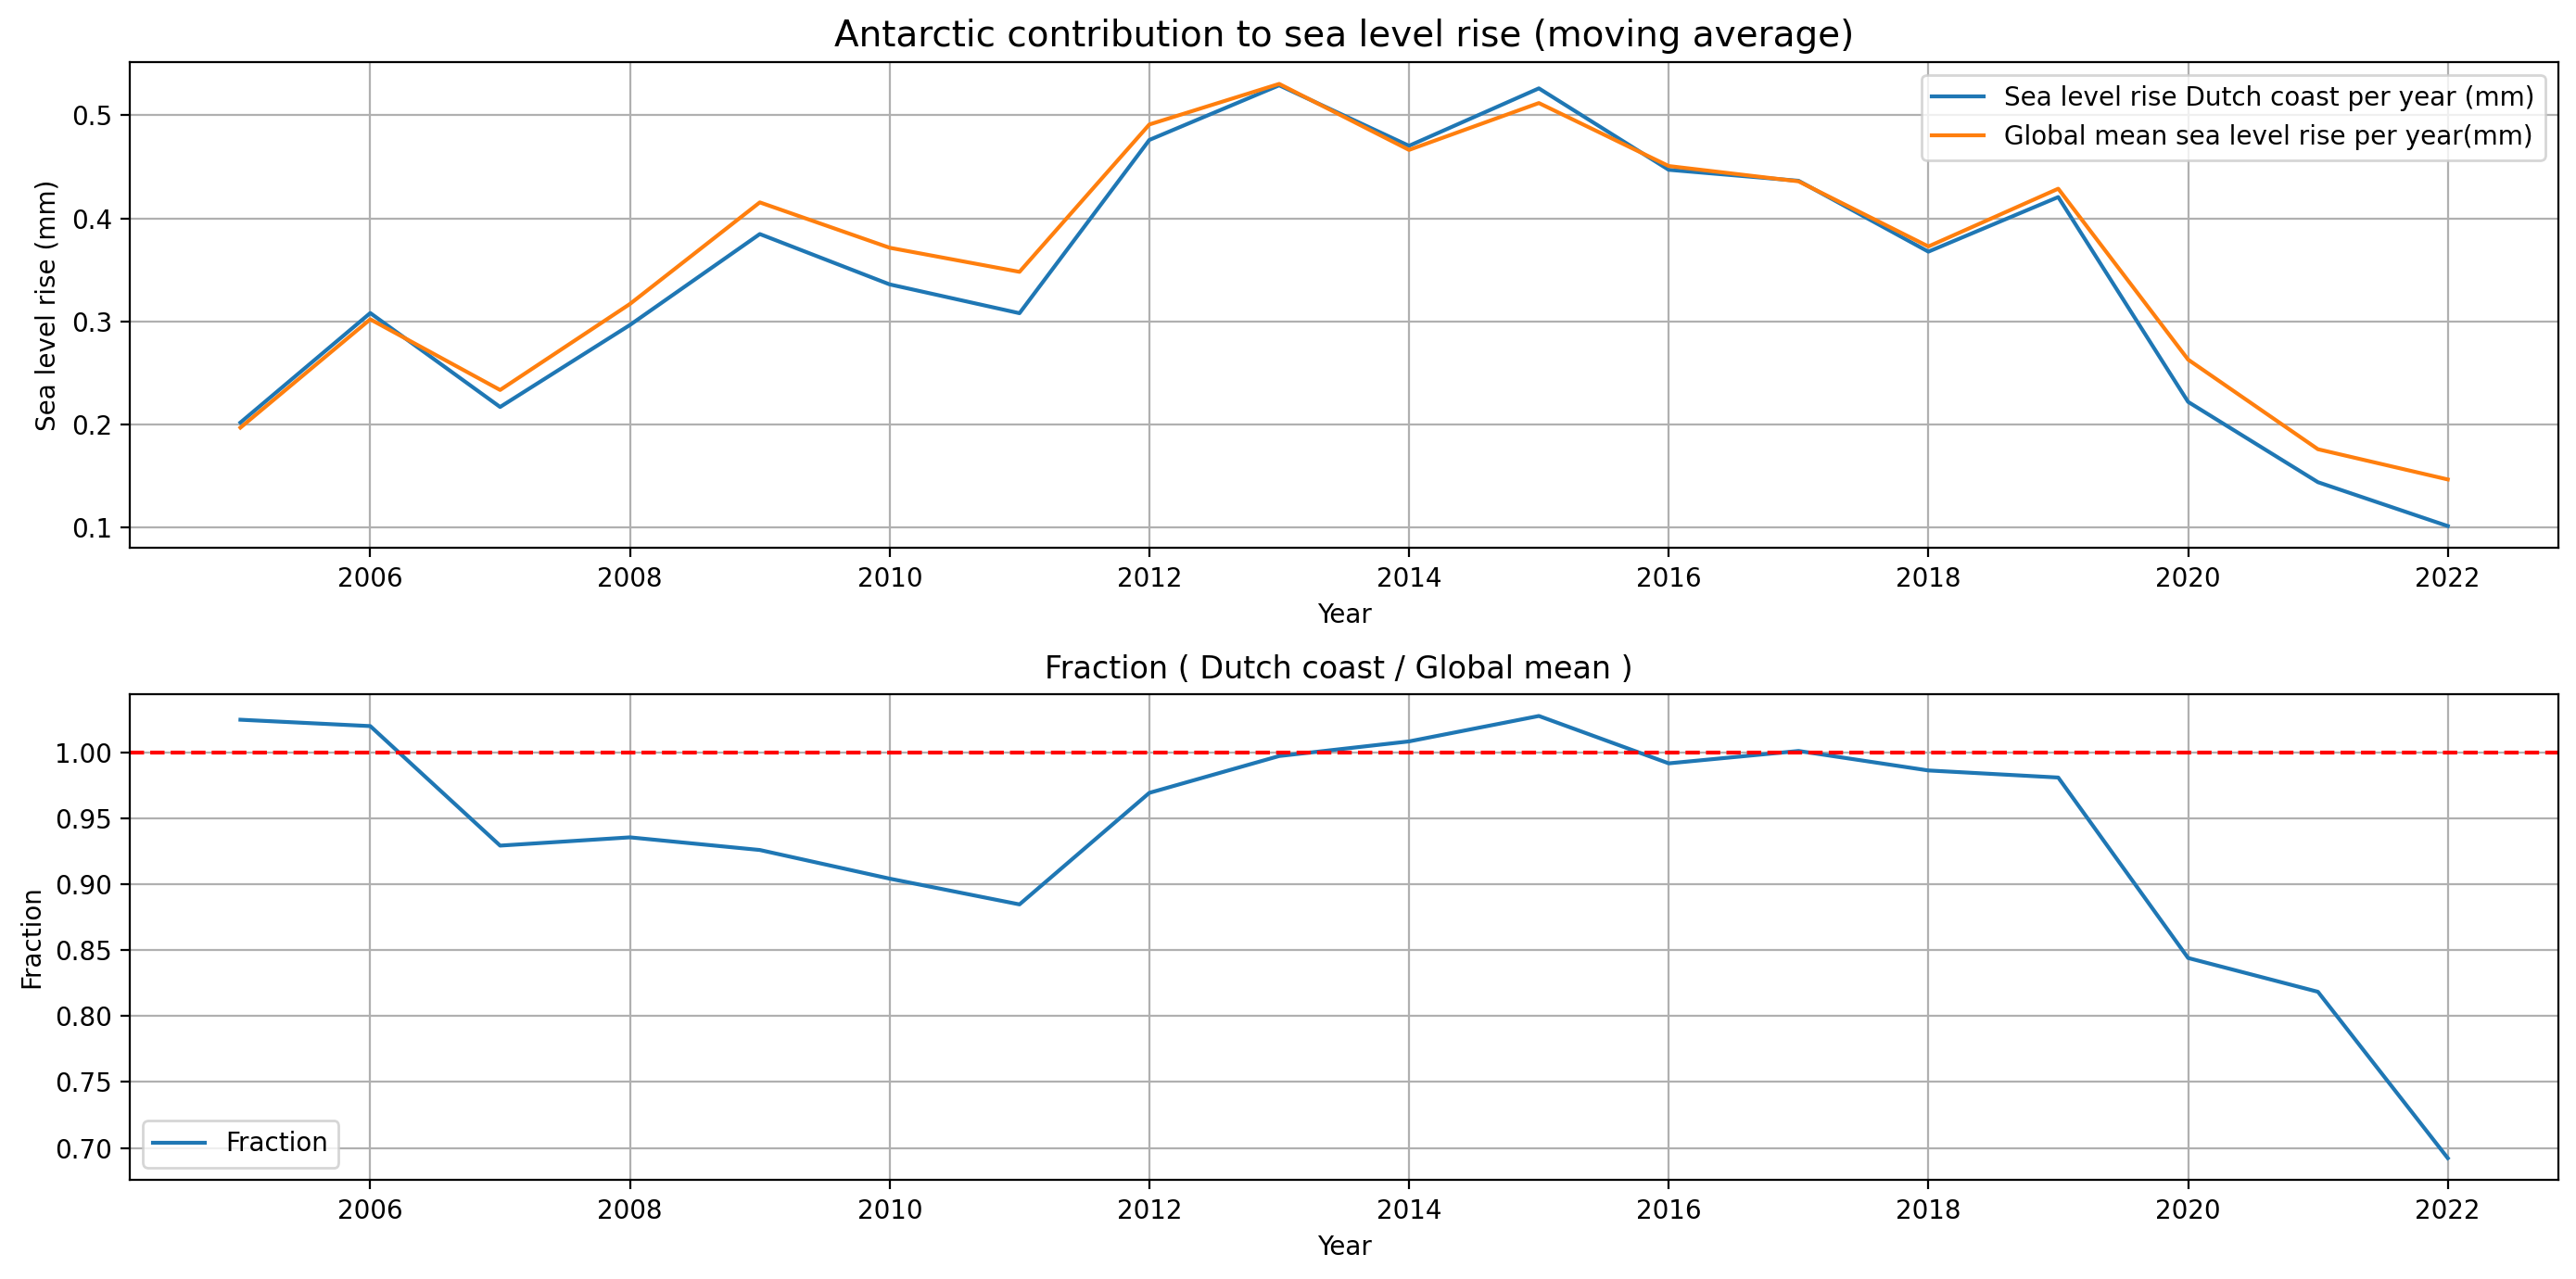

In [23]:
# Plot the sea level rise as a result of mass changes in Antarctica. Plot the corresponding global mean and the value for the Dutch coast

from matplotlib.ticker import MaxNLocator

# Plot the two different figures in one window (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

#Plot1
(dutch_c_5y*10).plot(ax=ax1, label='Sea level rise Dutch coast per year (mm)')  #translated to mm
(mean_w_5y*10).plot(ax=ax1, label='Global mean sea level rise per year(mm)')



ax1.set_title("Antarctic contribution to sea level rise (moving average)", fontsize=14)
ax1.set_xlabel("Year")
ax1.set_ylabel("Sea level rise (mm)")
ax1.legend()
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # whole numbers
ax1.grid()

# Plot2
fractionperyearrun.plot(ax=ax2, label='Fraction')
ax2.axhline(y=1, color='r', linestyle='--')

ax2.set_title("Fraction ( Dutch coast / Global mean ) ")
ax2.set_xlabel("Year")
ax2.set_ylabel("Fraction")
ax2.legend()
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))  # whole numbers
ax2.grid()

plt.tight_layout()
plt.show()


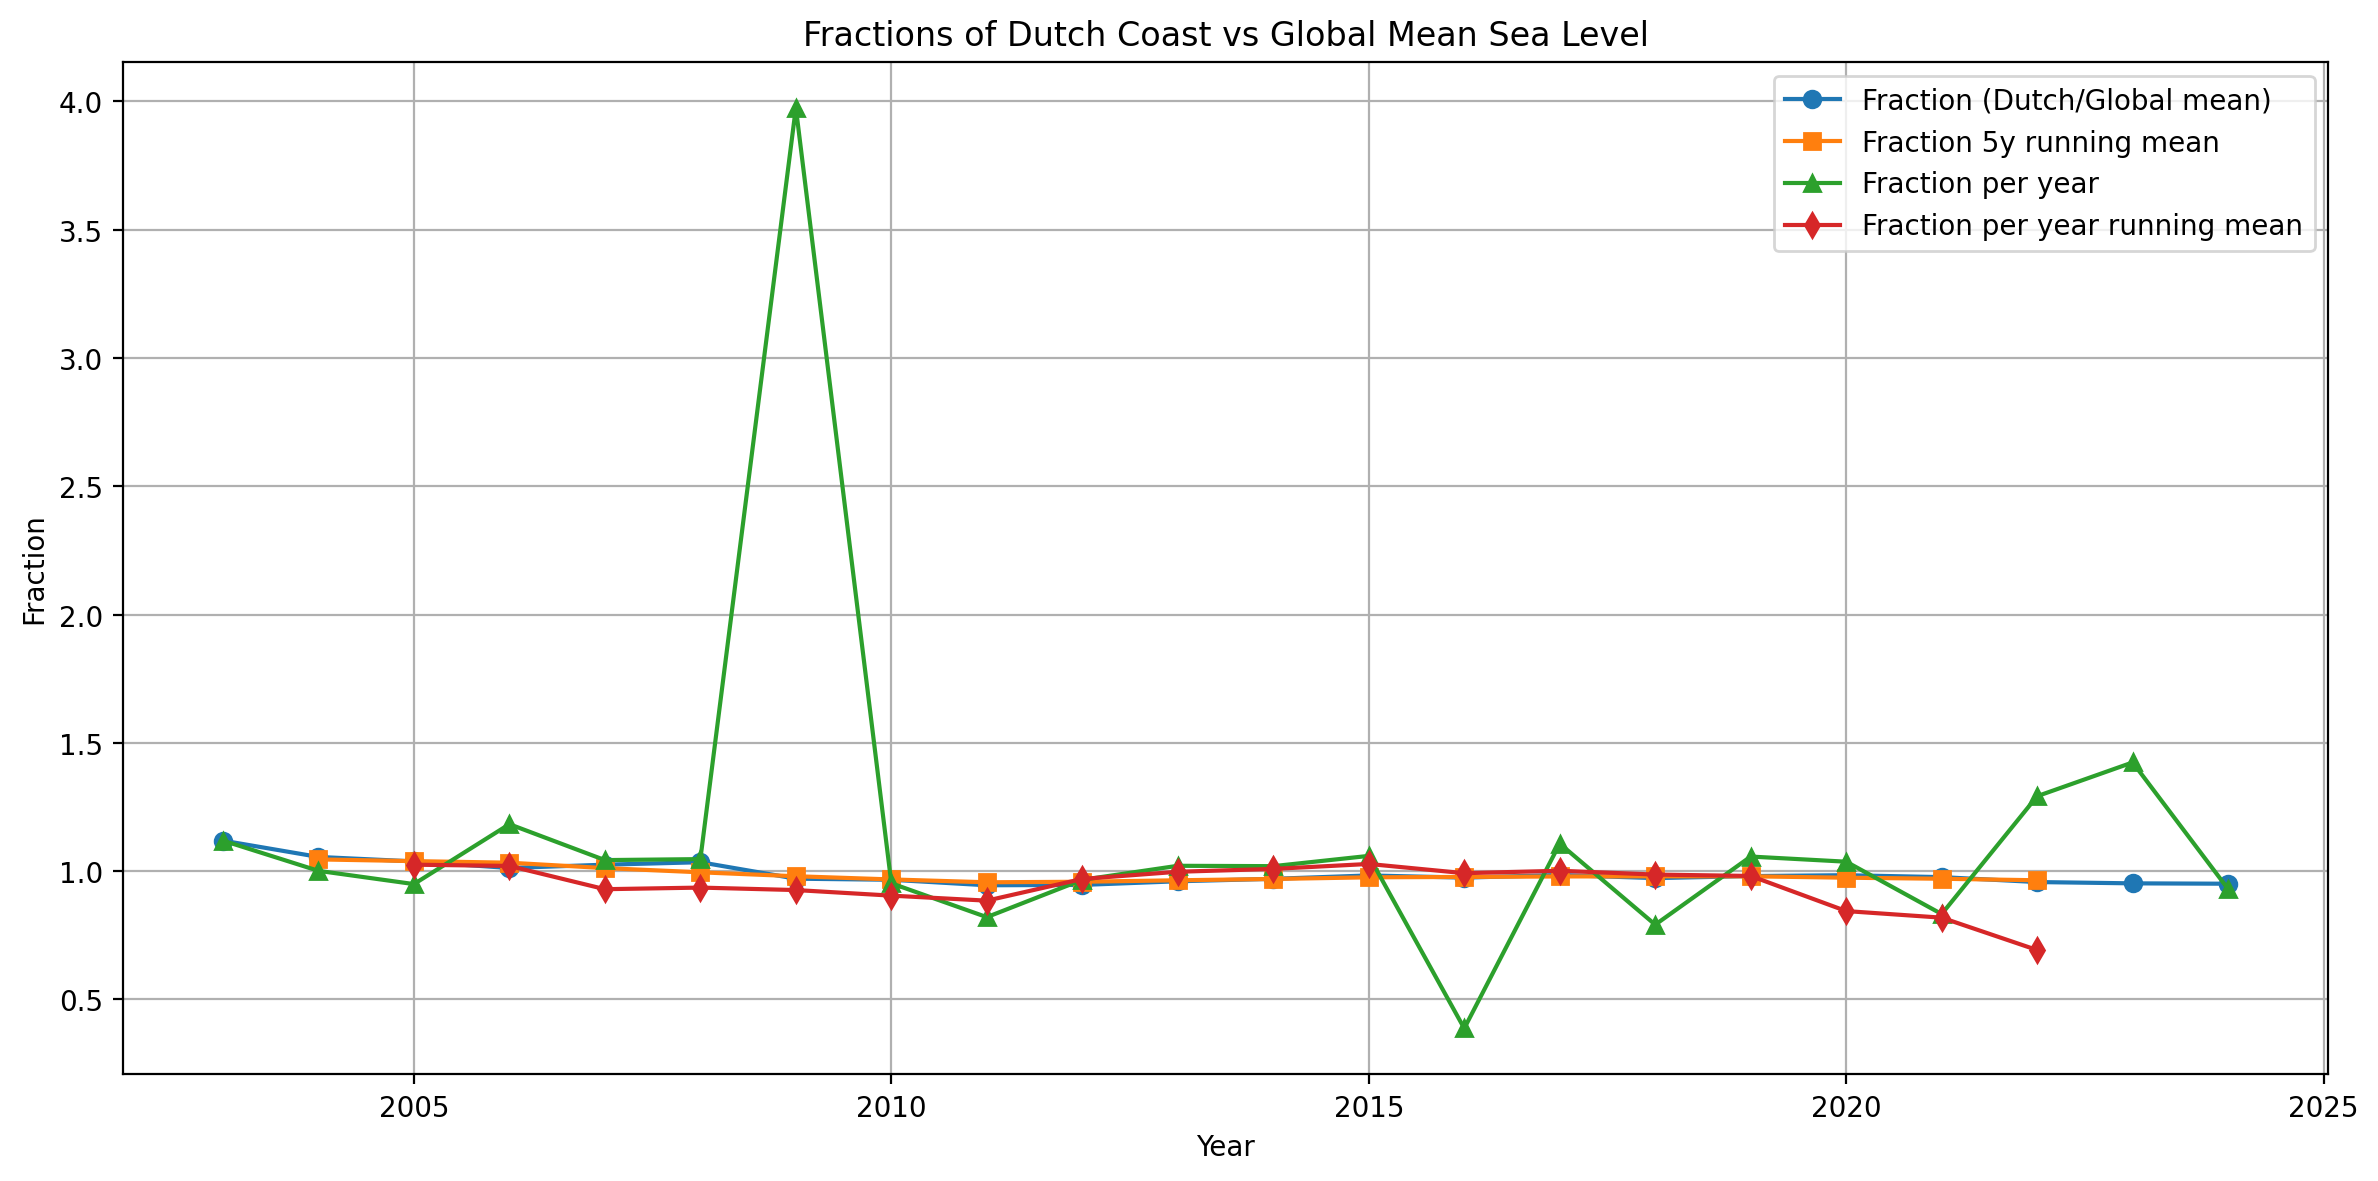

In [24]:
# compare the fractions calculated basted on cummulative data and yearly data and both with or without running mean. 

plt.figure(figsize=(12,6))

# Plot each fraction series
plt.plot(fraction.index, fraction, label='Fraction (Dutch/Global mean)', marker='o')
plt.plot(fraction_5y.index, fraction_5y, label='Fraction 5y running mean', marker='s')
plt.plot(fractionperyear.index, fractionperyear, label='Fraction per year', marker='^')
plt.plot(fractionperyearrun.index, fractionperyearrun, label='Fraction per year running mean', marker='d')

# Labels and title
plt.xlabel('Year')
plt.ylabel('Fraction')
plt.title('Fractions of Dutch Coast vs Global Mean Sea Level')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


In [15]:
# Compute the fraction for periods with a high or a low fraction. 


dutch1 = dutch_coast.loc[2007] - dutch_coast.loc[2002] 
world1 = mean_world.loc[2007] - mean_world.loc[2002] 
frac1 = dutch1/world1
print(frac1) 

dutch2 = dutch_coast.loc[2014] - dutch_coast.loc[2009] 
world2 = mean_world.loc[2014] - mean_world.loc[2009] 
frac2 = dutch2/world2
print(frac2) 

dutch3 = dutch_coast.loc[2017] - dutch_coast.loc[2012] 
world3 = mean_world.loc[2017] - mean_world.loc[2012] 
frac3 = dutch3/world3
print(frac3)

dutch4 = dutch_coast.loc[2024] - dutch_coast.loc[2019] 
world4 = mean_world.loc[2024] - mean_world.loc[2019] 
frac4 = dutch4/world4
print(frac4)


1.0249707055550477
0.9694727974501274
1.0278148162412897
0.6922428597839073


In [35]:
# Compare the mass change patterns for periods with the high fraction to periods with the low fraction. 

print(ant_y['dm'].sel(time='2002').squeeze().shape)

diff1 = ant_y['dm'].sel(time='2007').squeeze() - ant_y['dm'].sel(time='2002').squeeze()  # squeeze removes the time dimension (without dimension is (1,x,y) and now (x,y), with isel it is removed automatically. 
diff2 = ant_y['dm'].sel(time='2012').squeeze() - ant_y['dm'].sel(time='2007').squeeze()
diff3 = ant_y['dm'].sel(time='2018').squeeze() - ant_y['dm'].sel(time='2013').squeeze() 
diff4 = ant_y['dm'].sel(time='2024').squeeze() - ant_y['dm'].sel(time='2019').squeeze()

mean1 = diff1/5
mean2 = diff2/5
mean3 = diff3/5
mean4 = diff4/5


# plot the two difference figures
#fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 11))

# Plot the differences
#mean1.plot(ax=ax1, cmap='RdBu_r', add_colorbar=True, cbar_kwargs={'label':'Mass change [kg/m2]'})
#mean2.plot(ax=ax2, cmap='RdBu_r', add_colorbar=True, cbar_kwargs={'label':'Mass change [kg/m2]'})
#mean3.plot(ax=ax3, cmap='RdBu_r', add_colorbar=True, cbar_kwargs={'label':'Mass change [kg/m2]'})
#mean4.plot(ax=ax4, cmap='RdBu_r', add_colorbar=True, cbar_kwargs={'label':'Mass change [kg/m2]'})

# Add titles with fraction values
#ax1.set_title(f'Average mass change between 2002 and 2007 - HIGH') #, fraction = {frac1.values:.4f}')
#ax2.set_title(f'Average mass change between 2007 and 2012 - LOW') #, fraction = {frac2.values:.4f}')
#ax3.set_title(f'Average mass change between 2013 and 2018 - HIGH') #, fraction = {frac3.values:.4f}')
#ax4.set_title(f'Average mass change between 2019 and 2024 - LOW') # , fraction = {frac4.values:.4f}')


#plt.tight_layout()
#plt.show()

#print(ant_y['time'].values)

(97, 117)


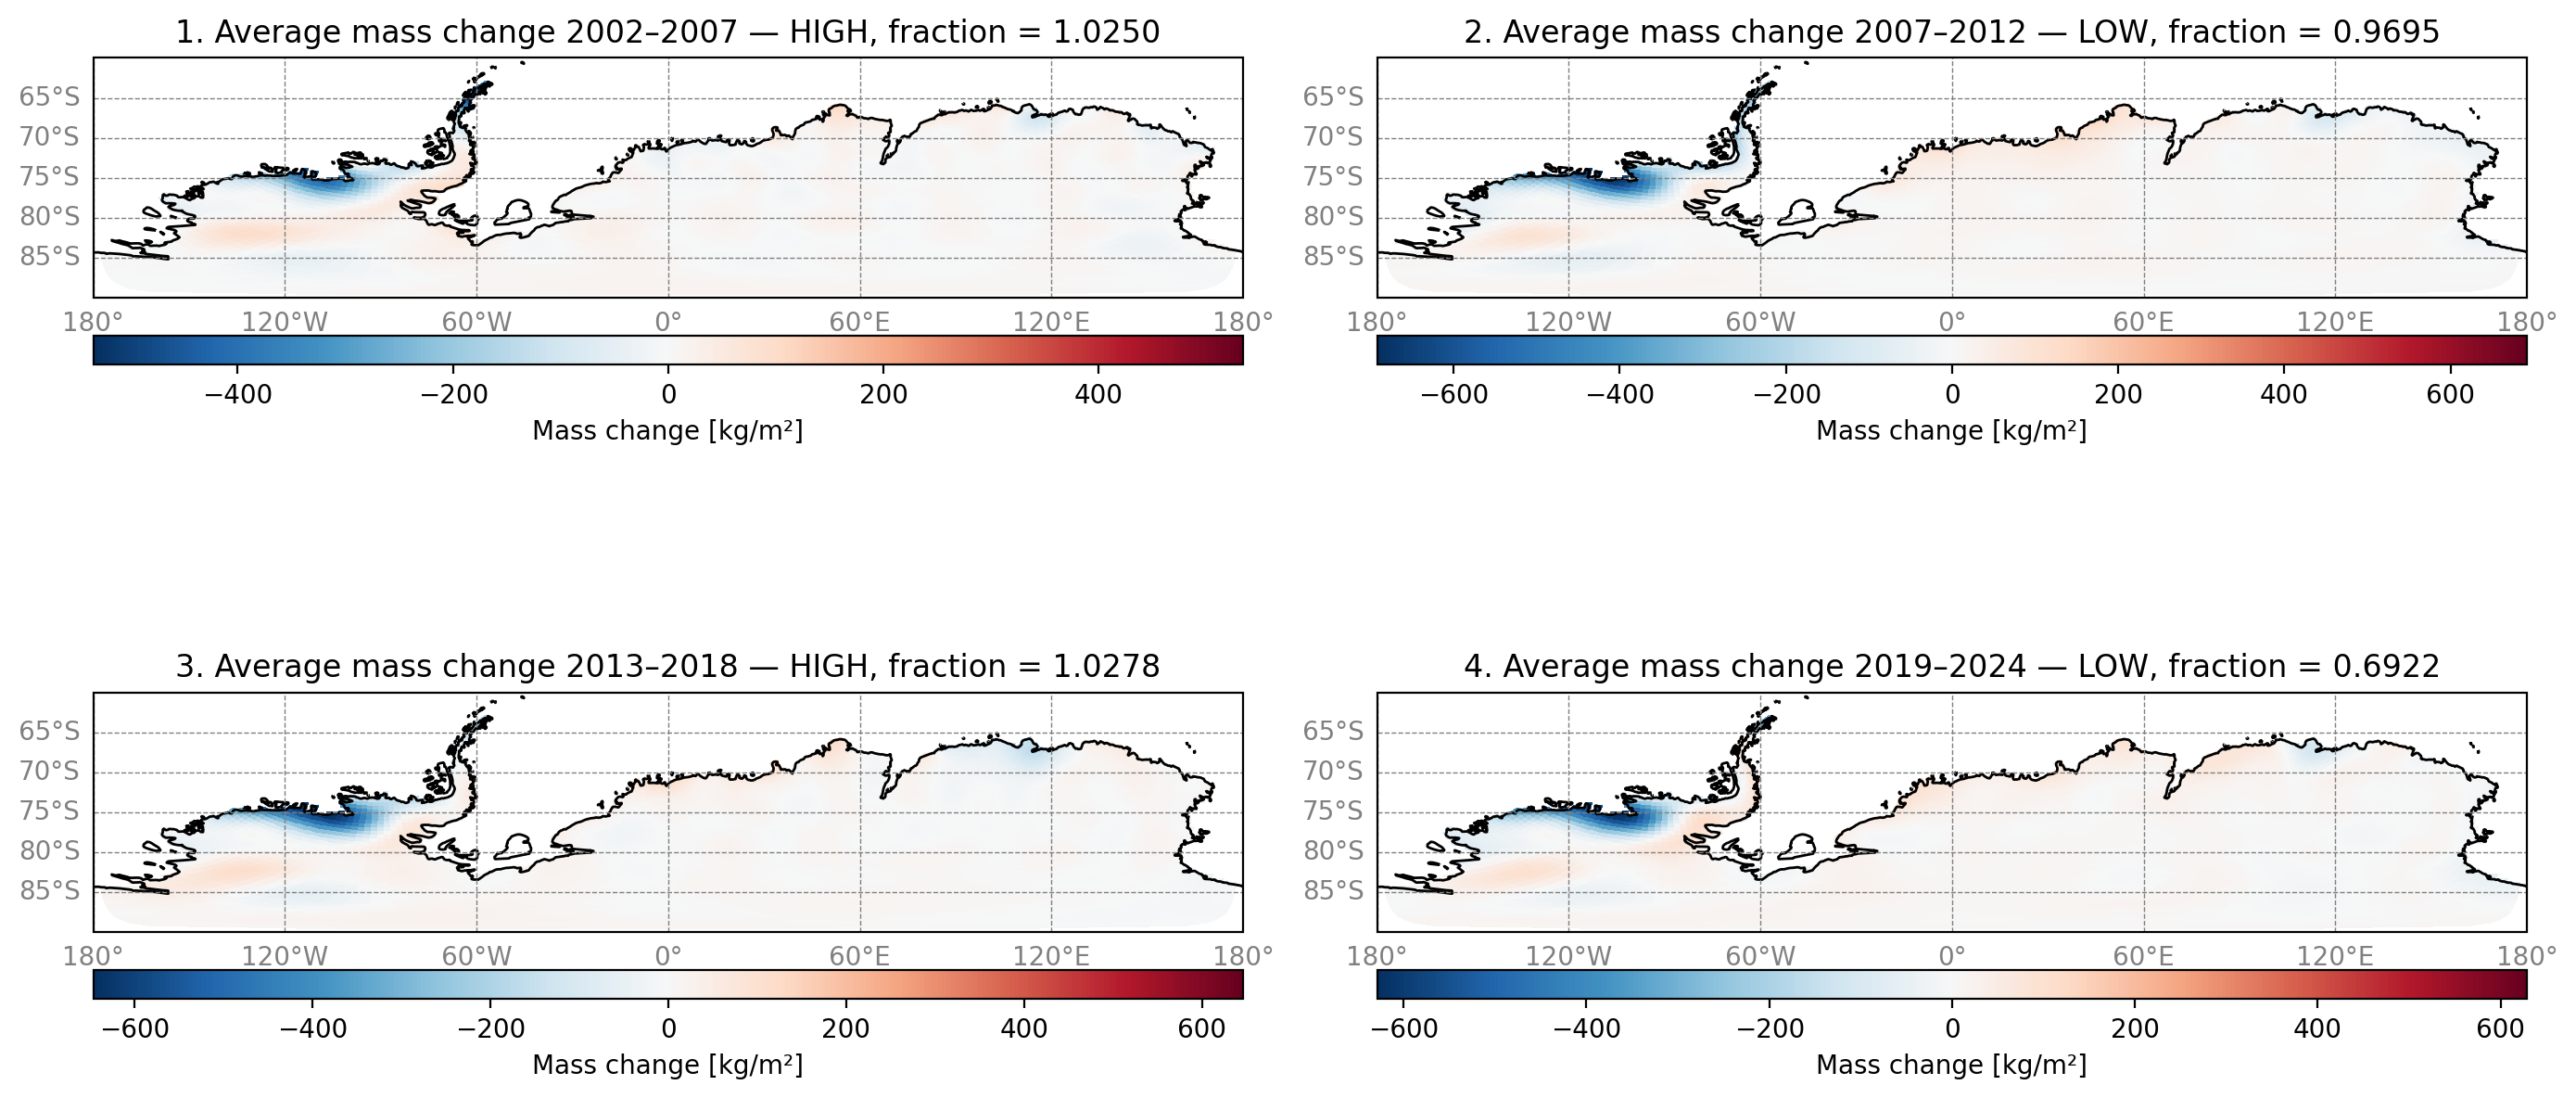

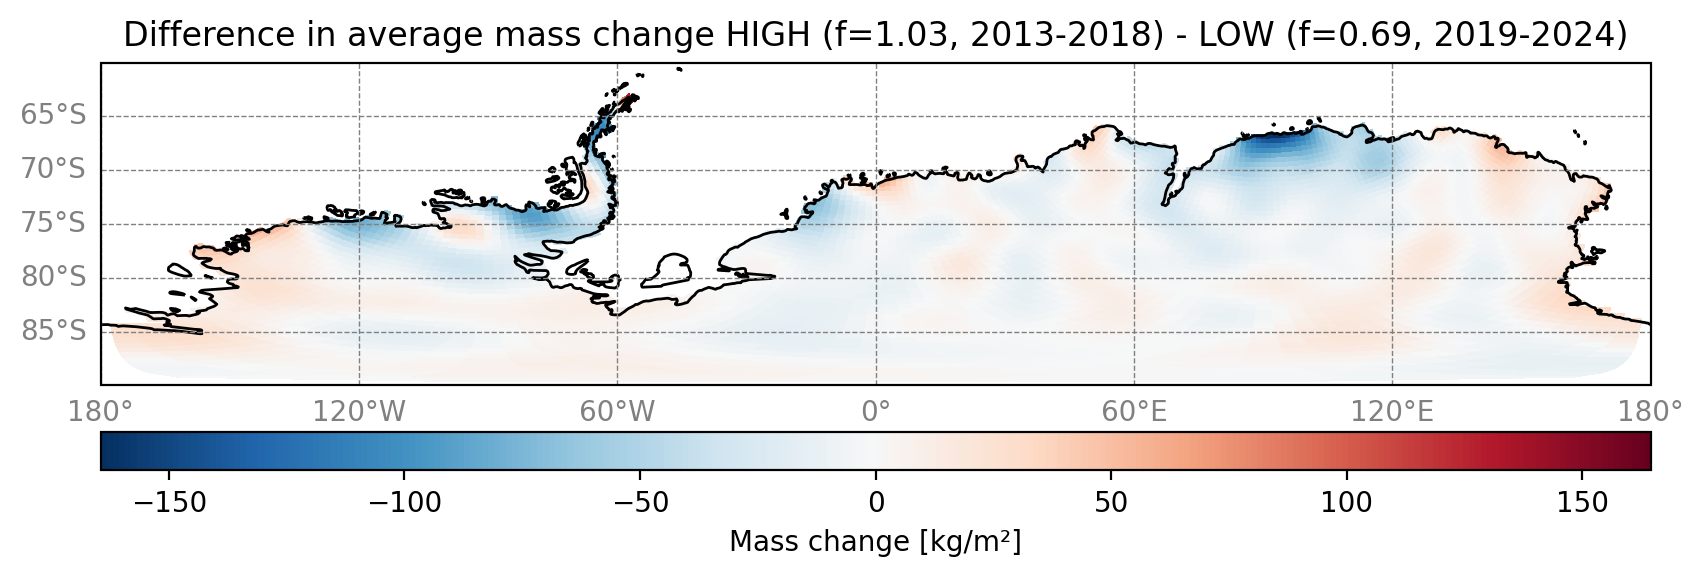

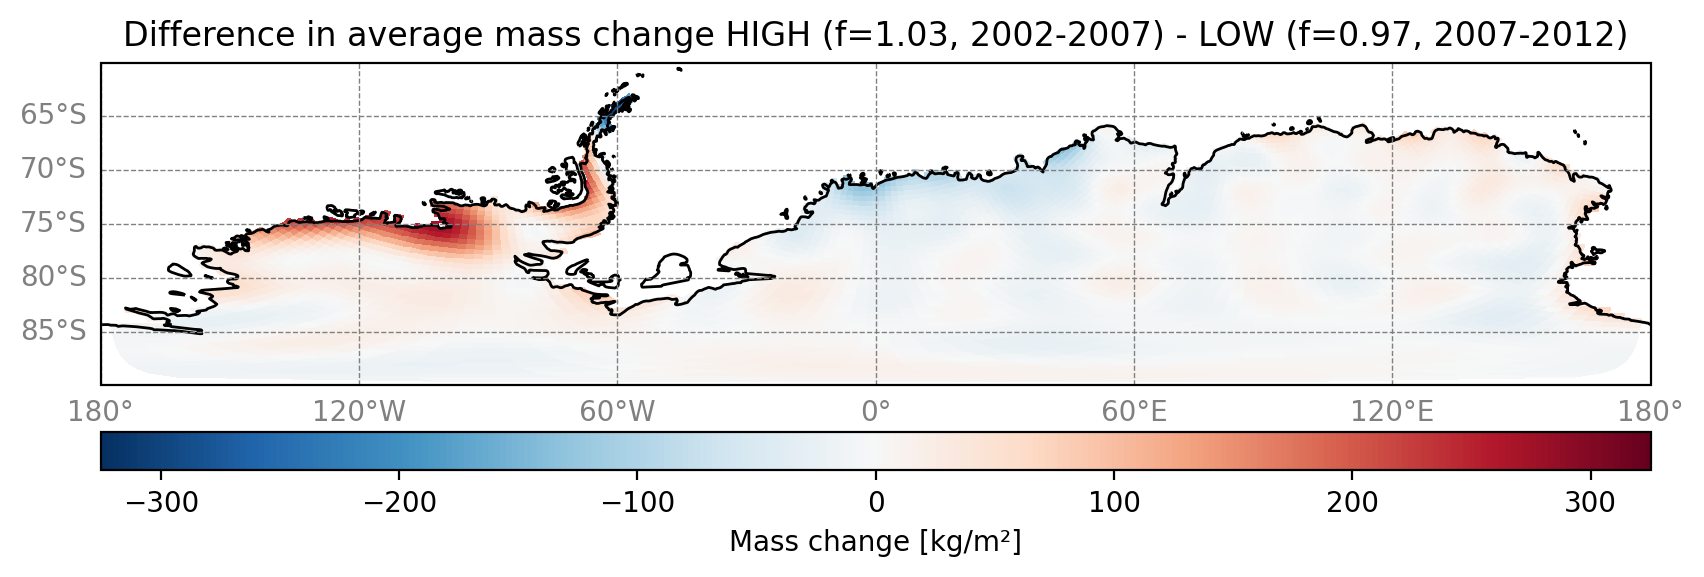

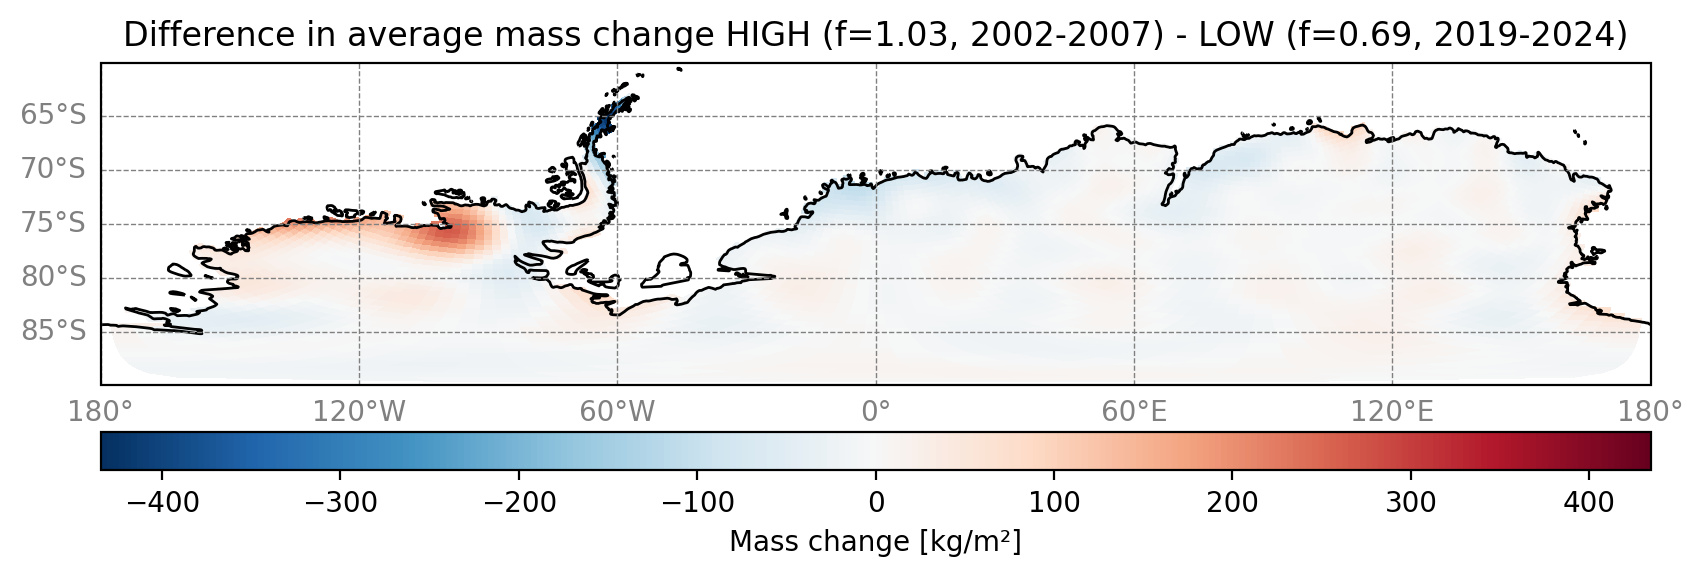

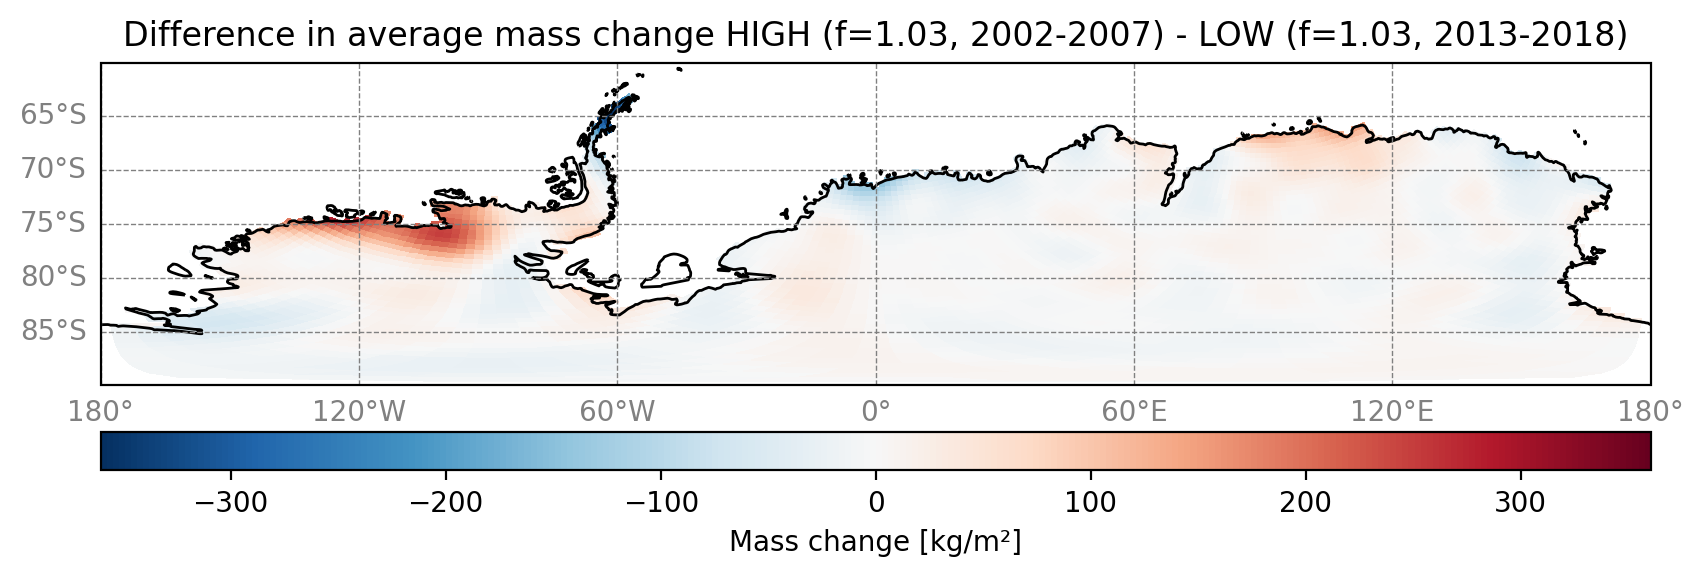

In [36]:
# Plot the mass change patterns for a period with a high and a low fraction

# lon/lat arrays
lon = ant_y['lon']
lat = ant_y['lat']

# ---- CREATE A TALLER FIGURE ----
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

ax1, ax2, ax3, ax4 = axes.flatten()
extent = [-180, 180, -90, -60]

def plot_field(ax, data, title):
    absmax = np.nanmax(np.abs(data))
    vmin, vmax = -absmax, absmax

    ax.set_extent(extent, crs=ccrs.PlateCarree())
    #ax.coastlines()
    gl = ax.gridlines(
        draw_labels=True,       # optional: show lat/lon labels
        linewidth=0.5,          # line thickness
        color='gray',           # color of gridlines
        linestyle='--'          # dashed style
    )

    # set the label colors to gray
    gl.top_labels = False      # usually top labels not needed
    gl.right_labels = False    # usually right labels not needed
    gl.xlabel_style = {'color': 'gray'}
    gl.ylabel_style = {'color': 'gray'}


    # >>> vertically stretch the map <<<
    ax.set_aspect(2.5)      # increase this number for more stretching
    ax.coastlines()

    mesh = ax.pcolormesh(
        lon, lat, data,
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title)

    plt.colorbar(
        mesh, ax=ax,
        orientation='horizontal',
        pad=0.05,
        aspect=40,
        #pad=0.08,
        #fraction=0.05,
        label='Mass change [kg/m²]'
    )


plot_field(ax1, mean1, f'1. Average mass change 2002–2007 — HIGH, fraction = {frac1:.4f}')
plot_field(ax2, mean2, f'2. Average mass change 2007–2012 — LOW, fraction = {frac2:.4f}')
plot_field(ax3, mean3, f'3. Average mass change 2013–2018 — HIGH, fraction = {frac3:.4f}')
plot_field(ax4, mean4, f'4. Average mass change 2019–2024 — LOW, fraction = {frac4:.4f}')



plt.tight_layout()
plt.show()


# Compute difference
#diff = mean4 - mean3
diff = mean3 - mean4  # high min low 
diff2 = mean1 - mean2
diff3 = mean1 - mean4

# Create a single figure
fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot using the same function
plot_field(ax, diff, f'Difference in average mass change HIGH (f=1.03, 2013-2018) - LOW (f=0.69, 2019-2024)')

plt.show()


# Create a single figure
fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot using the same function
plot_field(ax, diff2, f'Difference in average mass change HIGH (f=1.03, 2002-2007) - LOW (f=0.97, 2007-2012)')

plt.show()

# Create a single figure
fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot using the same function
plot_field(ax, diff3, f'Difference in average mass change HIGH (f=1.03, 2002-2007) - LOW (f=0.69, 2019-2024)')

plt.show()



# Compute difference
diff4 = mean1 - mean3  # HIGH (2002–2007) - LOW (2013–2018)

# Create a single figure
fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot using the same function
plot_field(
    ax,
    diff4,
    'Difference in average mass change HIGH (f=1.03, 2002-2007) - LOW (f=1.03, 2013-2018)'
)

plt.show()




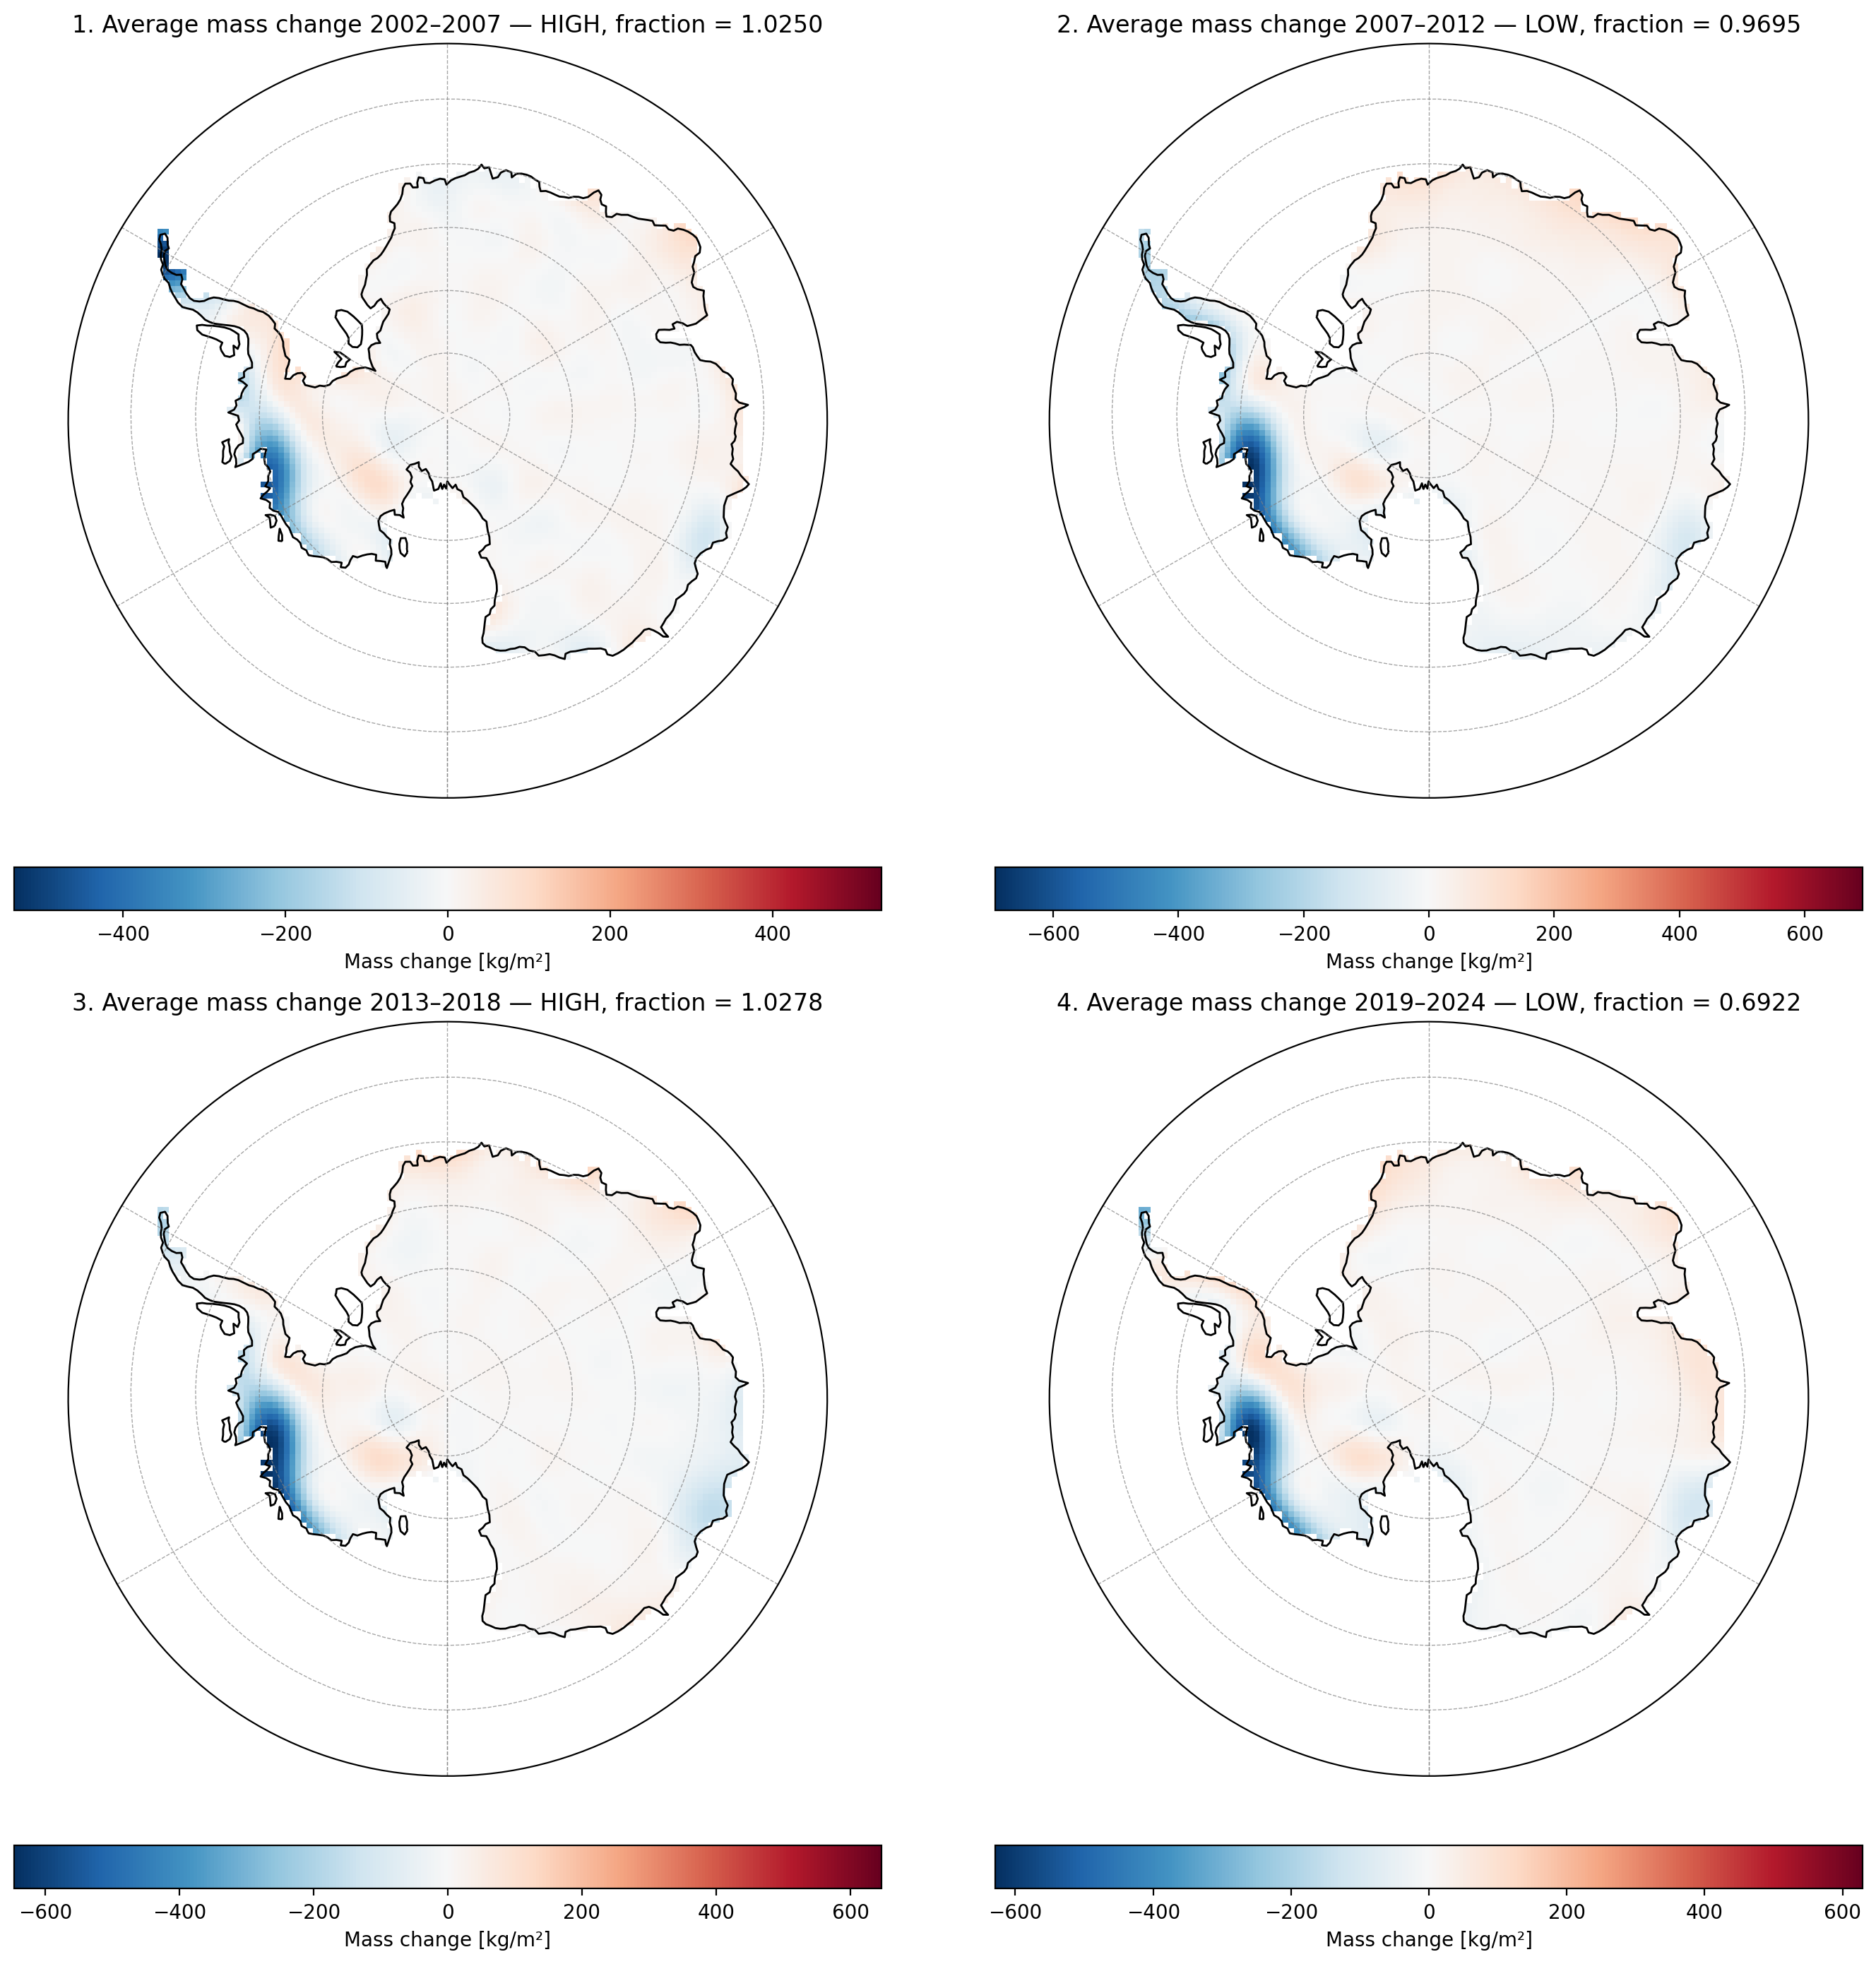

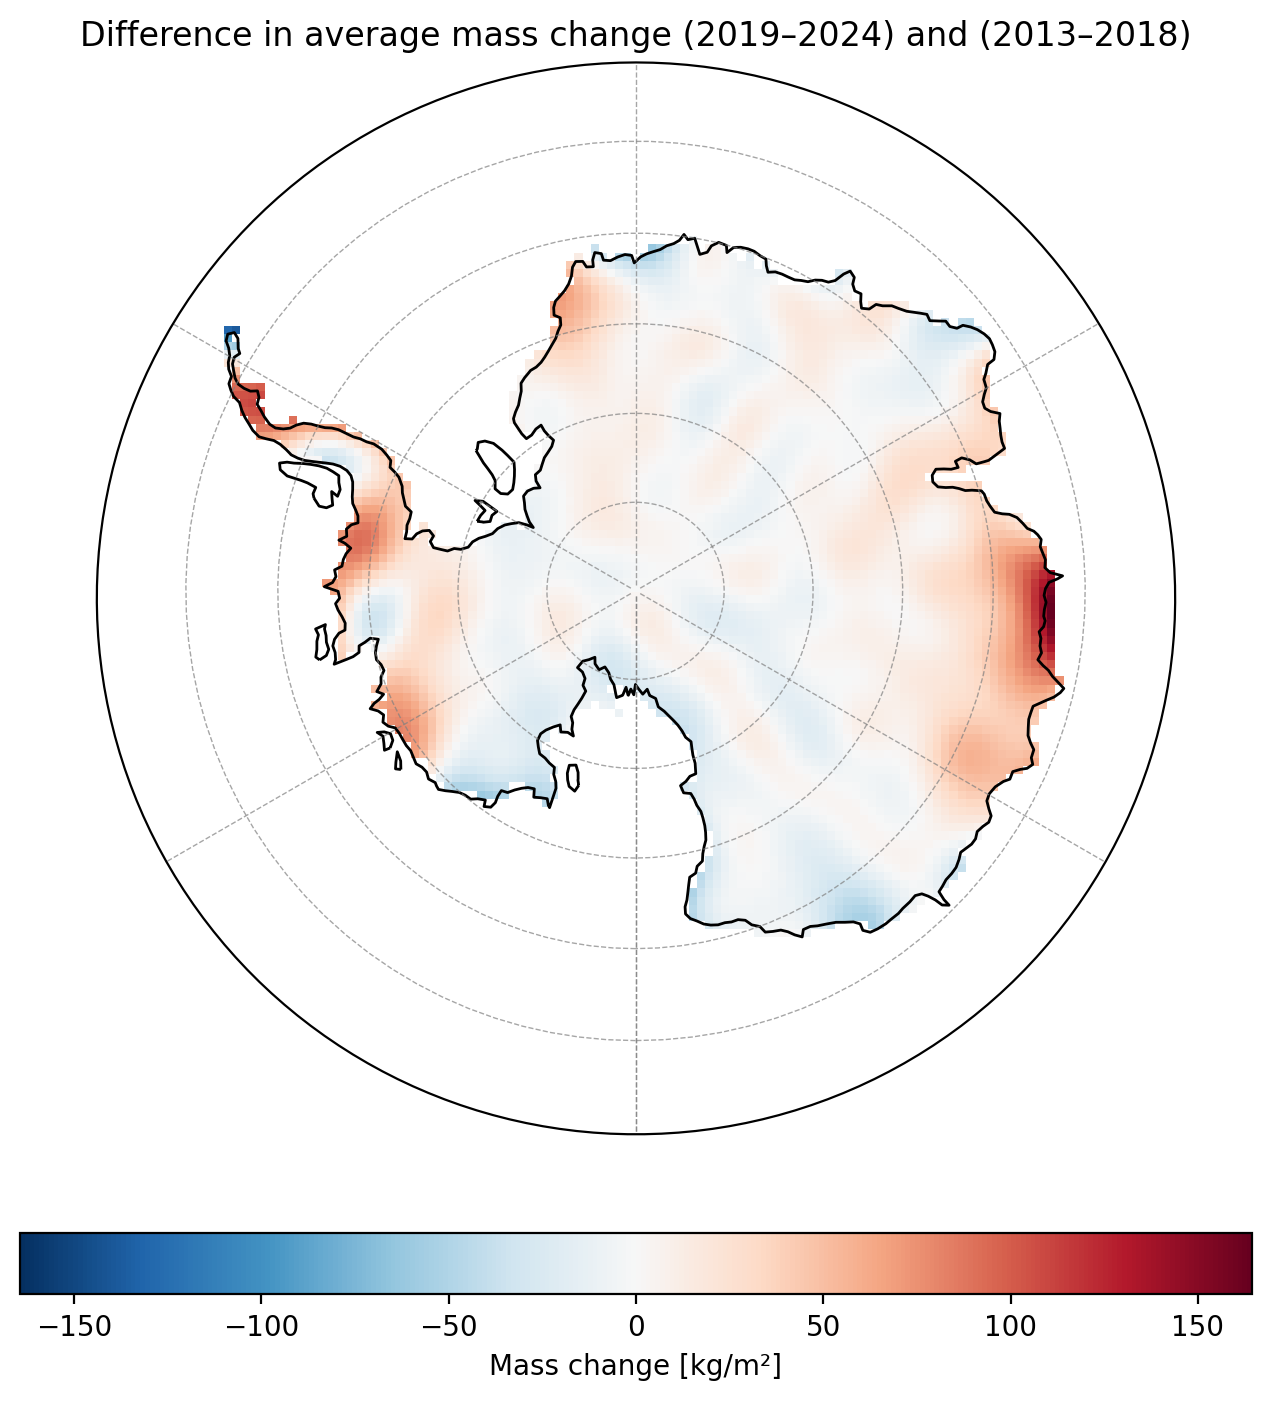

In [37]:
# Try to make a better polar projection

import matplotlib.path as mpath


extent = [-180, 180, -90, -60]

def plot_field_polar(ax, data, lon, lat, title, cmap='RdBu_r', unit='Mass change [kg/m²]'):
    # Symmetric color scale around zero
    absmax = np.nanmax(np.abs(data))
    vmin, vmax = -absmax, absmax

    # Avoid exact pole to prevent white dot
    lat_safe = np.clip(lat, -89.999, -60)

    # Plot
    
    mesh = ax.pcolormesh(
        lon, lat_safe, data,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    


    # Set Antarctic extent
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Coastlines
    ax.coastlines(resolution='110m', linewidth=1)

    # Gridlines
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.5,
        color='gray',
        linestyle='--',
        alpha=0.7
    )

    # Circular boundary
    theta = np.linspace(0, 2*np.pi, 200)
    circle = mpath.Path(np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + 0.5)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_title(title)

    # Colorbar
    plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.08, fraction=0.05, label=unit)

    return mesh

# ---- CREATE FIGURE ----
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 14),
    subplot_kw={'projection': ccrs.SouthPolarStereo()}
)

ax1, ax2, ax3, ax4 = axes.flatten()

plot_field_polar(ax1, mean1, lon, lat, f'1. Average mass change 2002–2007 — HIGH, fraction = {frac1:.4f}')
plot_field_polar(ax2, mean2, lon, lat, f'2. Average mass change 2007–2012 — LOW, fraction = {frac2:.4f}')
plot_field_polar(ax3, mean3, lon, lat, f'3. Average mass change 2013–2018 — HIGH, fraction = {frac3:.4f}')
plot_field_polar(ax4, mean4, lon, lat, f'4. Average mass change 2019–2024 — LOW, fraction = {frac4:.4f}')

plt.tight_layout()
plt.show()

# ---- DIFFERENCE PLOT ----
diff = mean4 - mean3

fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 8),
    subplot_kw={'projection': ccrs.SouthPolarStereo()}
)

plot_field_polar(ax, diff, lon, lat, f'Difference in average mass change (2019–2024) and (2013–2018)')

plt.show()
